## GINR CTD DATA 

### March 9th 2026

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
from datetime import timedelta, datetime
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import netCDF4 as nc4
from eccoseas.downscale import vertical
# import the necessary modules from eccoseas
from eccoseas.ecco import exf
from eccoseas.ecco import io
from eccoseas.downscale import hFac
from eccoseas.downscale import horizontal
import pandas as pd
import glob
from datetime import datetime, timedelta

In [2]:
file_path = '/Volumes/T7/thesis/Nuup_Kangerlua/GINR_CTD/CTD_2018.csv'
df = pd.read_csv(file_path)

In [3]:
df

,cast,datetime,latitude,longitude,depth_m,temperature_degC,salinity_psu,fluorescence,oxygen_umol_kg
0,GF18001,1/9/18 12:05,64.266467,-51.664433,0.990,-0.1021,32.2778,0.095140,317.479
1,GF18001,1/9/18 12:05,64.266467,-51.664433,1.980,-0.0979,32.2779,0.088781,317.625
2,GF18001,1/9/18 12:05,64.266467,-51.664433,2.971,-0.0974,32.2781,0.086881,317.232
3,GF18001,1/9/18 12:05,64.266467,-51.664433,3.961,-0.0694,32.2821,0.087621,317.089
4,GF18001,1/9/18 12:05,64.266467,-51.664433,4.951,-0.0669,32.2819,0.086256,317.246
...,...,...,...,...,...,...,...,...,...
31361,HS181217,12/17/18 14:19,64.125150,-51.876200,315.648,3.1610,33.7521,0.104580,294.552
31362,HS181217,12/17/18 14:19,64.125150,-51.876200,316.636,3.1732,33.7571,0.102990,294.656
31363,HS181217,12/17/18 14:19,64.125150,-51.876200,317.625,3.1804,33.7581,0.101970,294.663
31364,HS181217,12/17/18 14:19,64.125150,-51.876200,318.614,3.1816,33.7580,0.102790,294.802


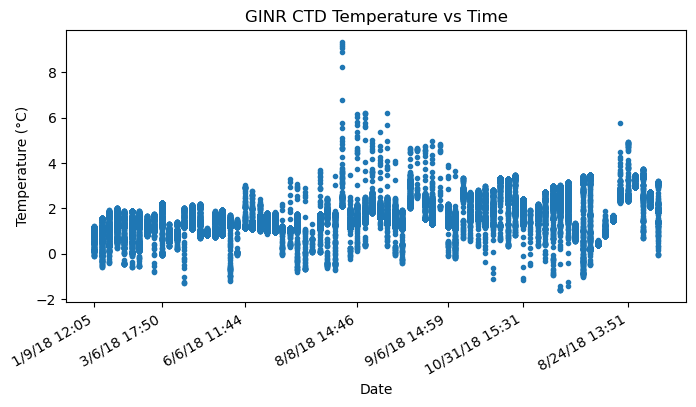

In [4]:
# plotting a timeseries of temperature for the ctd data:

plt.figure(figsize=(8,4))

plt.plot(df["datetime"], df["temperature_degC"], marker=".", linestyle="none")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title("GINR CTD Temperature vs Time")

plt.xticks(df["datetime"][::5000])   # change 20 to whatever spacing you want

plt.gcf().autofmt_xdate()
plt.show()


In [5]:
# convert the datetime column
df["datetime"] = pd.to_datetime(df["datetime"])

start = "2018-06-11"
end   = "2018-06-12"

mask = (df["datetime"] >= start) & (df["datetime"] < end)
df_range = df[mask]

/var/folders/p_/r3l2k0v15s16v1d1593p15400000gs/T/ipykernel_37165/1104276116.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["datetime"])


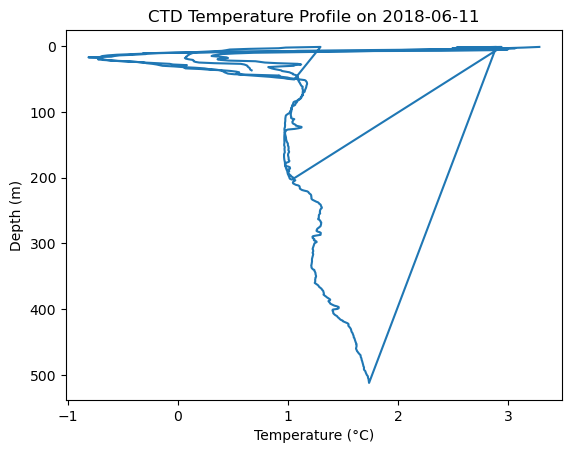

(811, 9)


In [6]:
# plotting an example profile from the ctd data:

plt.plot(df_range["temperature_degC"], df_range["depth_m"])
plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title(f"CTD Temperature Profile on {start}")
plt.show()

print(df[mask].shape)

### Now reading in my model:

In [7]:
# define the parameters that will be used in the data file
xc = np.fromfile('/Users/msharkey/Documents/MLML/FALL 2025/MS 274/lectures/week 8/my_model/XC720_540.bin', '>f8').reshape(720, 1)
#print(XC)
yc = np.fromfile('/Users/msharkey/Documents/MLML/FALL 2025/MS 274/lectures/week 8/my_model/YC720_540.bin', '>f8').reshape(540, 1)
#print(YC)
XC, YC = np.meshgrid(xc, yc)

delX = 3.595/720
delY = 1.078/540
xgOrigin = -52.8
ygOrigin = 63.8
n_rows = 540 # Ny
n_cols = 720 # Nx

# # recreate the grids that will be used in the model
# xc = np.arange(xgOrigin+delX/2, xgOrigin+n_cols*delX+delX/2, delX)
# yc = np.arange(ygOrigin+delY/2, ygOrigin+n_rows*delY+delY/2, delY)
# XC, YC = np.meshgrid(xc, yc)

# read in the bathymetry file
bathy = np.fromfile(
    '/Volumes/T7/thesis/Nuup_Kangerlua/L2_Nuup_Kangerlua_bathymetry.bin',
    '>f4'
).reshape(XC.shape)

depth = bathy
delR = np.array([1.00,    1.14,    1.30,    1.49,   1.70,
          1.93,    2.20,    2.50,    2.84,   3.21,
          3.63,    4.10,    4.61,    5.18,   5.79,
          6.47,    7.20,    7.98,    8.83,   9.73,
         10.69,   11.70,   12.76,   13.87,  15.03,
         16.22,   17.45,   18.70,   19.97,  21.27,
         22.56,   23.87,   25.17,   26.46,  27.74,
         29.00,   30.24,   31.45,   32.65,  33.82,
         34.97,   36.09,   37.20,   38.29,  39.37, 40.45, 41.53])

z_bottom = np.cumsum(delR)
z_top = np.hstack([np.array([0]), z_bottom[:-1]])
z = (z_bottom + z_top)/2
print(len(z))
print(z)

hFacC = hFac.create_hFacC_grid(bathy, delR)

land_mask_3d = (hFacC == 0)
land_mask_2d = np.all(land_mask_3d, axis=0)

47
[5.00000e-01 1.57000e+00 2.79000e+00 4.18500e+00 5.78000e+00 7.59500e+00
 9.66000e+00 1.20100e+01 1.46800e+01 1.77050e+01 2.11250e+01 2.49900e+01
 2.93450e+01 3.42400e+01 3.97250e+01 4.58550e+01 5.26900e+01 6.02800e+01
 6.86850e+01 7.79650e+01 8.81750e+01 9.93700e+01 1.11600e+02 1.24915e+02
 1.39365e+02 1.54990e+02 1.71825e+02 1.89900e+02 2.09235e+02 2.29855e+02
 2.51770e+02 2.74985e+02 2.99505e+02 3.25320e+02 3.52420e+02 3.80790e+02
 4.10410e+02 4.41255e+02 4.73305e+02 5.06540e+02 5.40935e+02 5.76465e+02
 6.13110e+02 6.50855e+02 6.89685e+02 7.29595e+02 7.70585e+02]


In [8]:
# use my grid bathymetry
mooring_map = np.copy(bathy)

# find nearest grid point function 
def nearest_point(XC, YC, lon, lat):
    dist2 = (XC - lon)**2 + (YC - lat)**2
    return np.unravel_index(np.argmin(dist2), dist2.shape)

# GINR mooring (6/11/2018)
j1, i1 = nearest_point(XC, YC, -50.50515, 64.72125)
mooring_map[j1, i1] = 1

# # mooring 2 (mid-fjord)
# j2, i2 = nearest_point(XC, YC, -51.3, 64.6)
# mooring_map[j2, i2] = 2

# # mooring 3 (near glacier terminus)
# j3, i3 = nearest_point(XC, YC, -49.9, 64.41)
# mooring_map[j3, i3] = 3


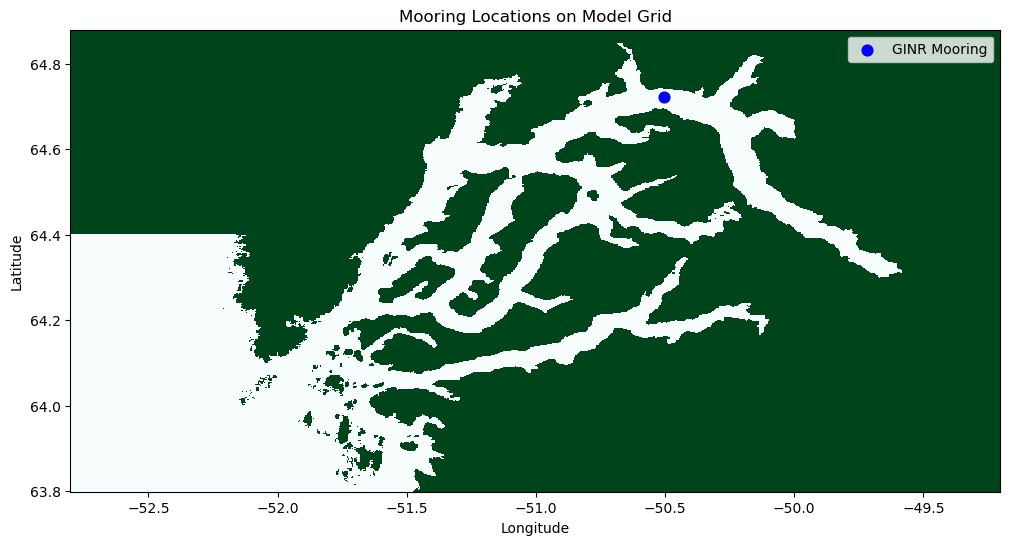

461
459


In [9]:
plt.figure(figsize=(12,6))

# mask out the land
# hfac_masked = np.ma.masked_where(hfacC[0,:,:] == 0, hfacC[0,:,:])

# # just want to plot a solid ocean and land 
# ocean_blue = "#b3d9ff"  #light blue color code
# land_white = "#ffffff"  
# cmap = ListedColormap([ocean_blue, ocean_blue])  # all ocean values = light blue
plt.pcolormesh(XC, YC, land_mask_2d, cmap = 'BuGn', vmin=0, vmax=1)

# plot moorings using lon/lat
# plt.scatter(lon_ctd, lat_ctd, color='red', s=200, edgecolor='black', label='Mooring 1 (GEM)')
plt.scatter(XC[j1, i1], YC[j1, i1], s=60, c='blue', label='GINR Mooring')
# plt.scatter(XC[j2, i2], YC[j2, i2], s=80, c='green', edgecolor='k', label='Virtual Mooring 2')
# plt.scatter(XC[j3, i3], YC[j3, i3], s=80, c='hotpink', edgecolor='k', label='Virtual Mooring 3')

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Mooring Locations on Model Grid")
plt.legend()
plt.show()
print(j1)
print(i1)

In [10]:
# i have TS data for level 19 (not exactly sure why) 
# here im reading in the TS_AW_daily_snap data and making lists

model_output = "/Volumes/T7/thesis/Nuup_Kangerlua/run/diags"

def read_aw_level_mooring(j_moor, i_moor):
    theta_list = []
    salt_list = []
    iter_list = []

    ts_files = sorted(glob.glob(
        os.path.join(model_output, "TS_AW_daily_snap", "TS_AW_daily_snap.*.data")))

    n_rows = 540
    n_cols = 720

    for ts_file in ts_files:
        iter_str = ts_file.split(".")[-2]
        iteration = int(iter_str)

        TS = np.fromfile(ts_file, ">f4").reshape(2, n_rows, n_cols)
        THETA_2d = TS[0]
        SALT_2d = TS[1]

        theta_list.append(THETA_2d[j_moor, i_moor])
        salt_list.append(SALT_2d[j_moor, i_moor])
        iter_list.append(iteration)

    iters = np.array(iter_list)
    THETA_aw = np.array(theta_list)
    SALT_aw = np.array(salt_list)

    return iters, THETA_aw, SALT_aw

In [11]:
# then i convert the model depth level to meters

delR = np.asarray(delR)
z_centers = np.cumsum(delR) - 0.5 * delR

aw_k = 18   # index for model level 19
aw_depth = z_centers[aw_k]

print("model AW depth (m):", aw_depth)

model AW depth (m): 68.68499999999999


In [12]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["cast"] = df["cast"].astype(str).str.strip()

cast_names = df["cast"].unique()

rows = []

for cast in cast_names:
    
    # get just one cast
    cast_df = df[df["cast"] == cast].copy()
    
    # find how far each CTD depth is from the model AW depth
    cast_df["depth_diff"] = abs(cast_df["depth_m"] - aw_depth)
    
    # take the row with the smallest depth difference
    closest_row = cast_df.loc[cast_df["depth_diff"].idxmin()]
    
    rows.append(closest_row)

df_aw_match = pd.DataFrame(rows)

print(df_aw_match[["cast", "datetime", "depth_m", "temperature_degC", "salinity_psu"]].head())

         cast            datetime  depth_m  temperature_degC  salinity_psu
68    GF18001 2018-01-09 12:05:00   68.316            0.2115       32.4402
389   GF18005 2018-01-09 13:10:00   68.316            0.1519       32.3764
1007  GF18006 2018-01-09 14:04:00   68.317            0.4436       32.5015
1598  GF18007 2018-01-09 15:31:00   68.317            0.7496       32.4925
2144  GF18008 2018-03-06 11:59:00   68.316            0.5497       32.9720


In [13]:
# calling the the function for reading my model:

iters, THETA_aw, SALT_aw = read_aw_level_mooring(j1, i1)

model_start = datetime(2018, 1, 1, 0, 0, 0)   # change if needed
deltaT = 30                                    # change if needed

time_dates = pd.to_datetime([
    model_start + timedelta(seconds=int(it) * deltaT) for it in iters
])

print("First model time:", time_dates[0])
print("Last model time:", time_dates[-1])

First model time: 2044-01-02 12:00:00
Last model time: 2044-12-10 12:00:00


In [14]:
# now i want to match up my model with the ctd data
# using the datetime for both 

model_temp_match = []
model_salt_match = []
model_time_match = []

for ctd_time in df_aw_match["datetime"]:
    t = np.argmin(np.abs(time_dates - ctd_time))
    model_temp_match.append(THETA_aw[t])
    model_salt_match.append(SALT_aw[t])
    model_time_match.append(time_dates[t])

df_aw_match["model_time"] = model_time_match
df_aw_match["model_temp_aw"] = model_temp_match
df_aw_match["model_salt_aw"] = model_salt_match

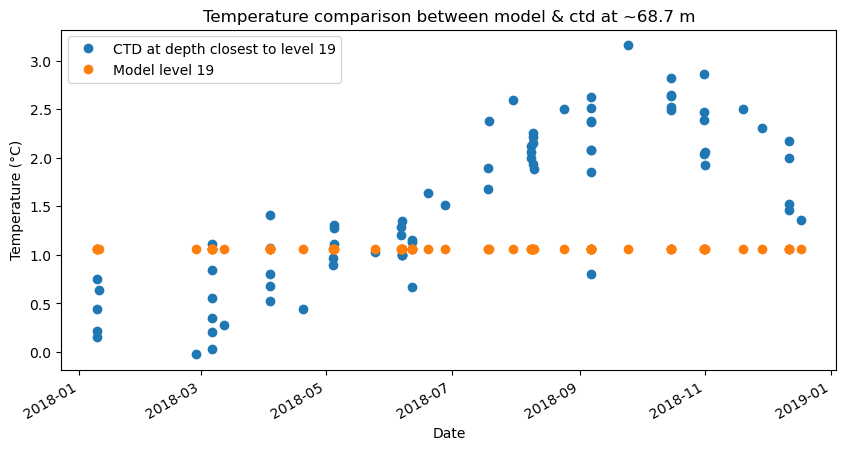

In [15]:
plt.figure(figsize=(10,5))
plt.plot(df_aw_match["datetime"], df_aw_match["temperature_degC"], "o", label="CTD at depth closest to level 19")
plt.plot(df_aw_match["datetime"], df_aw_match["model_temp_aw"], "o", label="Model level 19")

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.title(f"Temperature comparison between model & ctd at ~{aw_depth:.1f} m")
plt.legend()
plt.gcf().autofmt_xdate()
plt.show()

In [16]:
# below i am trying to read in 3D TS data from my model, but realized i dont have that! 

In [20]:
model_output = "/Volumes/T7/thesis/Nuup_Kangerlua/run/diags"

# here I read in the 3D model output and create arrays for theta, salt, and wvel at each mooring location
def read_3d_mooring(j_moor, i_moor):

    theta_list = []  # theta profiles over time
    salt_list  = []  # salinity profiles over time
    #wvel_list  = []  # vertical velocity profiles over time
    iter_list  = []  # iteration numbers

    # here I'm finding all 3D T/S snapshot files
    ts_files = sorted(glob.glob(os.path.join(model_output, "TS_daily", "TS_daily.*.data")))

    Nr     = 47   # number of vertical levels
    n_rows = 540  # model grid size (j direction)
    n_cols = 720  # model grid size (i direction)

    for ts_file in ts_files:

        # get the iteration number from the filename
        iter_str  = ts_file.split(".")[-2]
        iteration = int(iter_str)

        # here I load the 3D theta/salt fields
        TS = np.fromfile(ts_file, ">f4").reshape(2, Nr, n_rows, n_cols)
        THETA_3d = TS[0]
        SALT_3d  = TS[1]

        # # now I load the matching WVEL file (skipping if it's missing)
        # w_file = os.path.join(model_output, "WVEL_3D_snap", f"WVEL_3D_snap.{iter_str}.data")
        # if not os.path.isfile(w_file):
        #     print(f"Skipping {iteration}: WVEL file missing")
        #     continue

        # WVEL_3d = np.fromfile(w_file, ">f4").reshape(Nr, n_rows, n_cols)

        # now I'm extracting the vertical column at the mooring point
        theta_list.append(THETA_3d[:, j_moor, i_moor])
        salt_list.append(SALT_3d[:,  j_moor, i_moor])
        # wvel_list.append(WVEL_3d[:,  j_moor, i_moor])
        iter_list.append(iteration)

    # turning the lists into arrays for easier plotting later
    iters    = np.array(iter_list)
    THETA_ts = np.array(theta_list)
    SALT_ts  = np.array(salt_list)
    # WVEL_ts  = np.array(wvel_list)

    return iters, THETA_ts, SALT_ts
    #, WVEL_ts


In [21]:
# here i get the ctd date/time:

df["datetime"] = pd.to_datetime(df["datetime"])

ctd_date = df["datetime"].iloc[0]
print(ctd_date)

2018-01-09 12:05:00


In [22]:
iters, THETA1, SALT1 = read_3d_mooring(j1, i1)

print(len(iters))

0


In [23]:
iters1, THETA1, SALT1 = read_3d_mooring(j1, i1)

In [24]:
# # here im plotting the theta profiles at a given date for each mooring
# moorings = [
#     ("Virtual Mooring 1 (GEM)", j1, i1, THETA1, "blue")]
#     # ("Virtual Mooring 2",       j2, i2, THETA2, "green"),
#     # ("Virtual Mooring 3",       j3, i3, THETA3, "hotpink")]

# # date i want to plot (year, month, day, hour)
# date = datetime(2017, 2, 22, 12)

# # here i find the model time closest to this date
# t = np.argmin(np.abs(np.array(time_dates) - date))

# delR = np.asarray(delR)
# z_centers = np.cumsum(delR) - 0.5 * delR

# plt.figure(figsize=(6, 7))

# for label, j, i, THETA_ts, color in moorings:

#     # temperature profile at this time (1D over depth)
#     theta_col = THETA_ts[t, :]

#     # wet mask at this mooring
#     wet_mask = hfacC[:, j, i] > 0

#     theta_wet = theta_col[wet_mask]
#     depth_wet = z_centers[wet_mask]

#     plt.plot(theta_wet, depth_wet, label=label, color=color)

# plt.gca().invert_yaxis()
# plt.xlabel("Temperature (°C)")
# plt.ylabel("Depth (m)")
# plt.title(f"Model Temperature Profiles at Virtual Moorings ({date})")
# plt.grid(linestyle="--", linewidth=0.5, alpha=0.5)
# plt.legend()
# plt.show()

In [16]:

# make sure CTD datetime column is datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# choose the CTD cast you want to compare
cast_name = "GF18001"
df_cast = df[df["cast"] == cast_name].copy()

# get the CTD cast time
ctd_date = df_cast["datetime"].iloc[0]

# read model output at the mooring location
iters, THETA1, SALT1 = read_3d_mooring(j1, i1)

# convert model iterations to actual dates
model_start = datetime(2017, 1, 1, 0, 0, 0)   # change if needed
deltaT = 15                                    # change if needed

time_dates = [model_start + timedelta(seconds=int(it) * deltaT) for it in iters]
time_dates = pd.to_datetime(time_dates)

# find closest model output time to the CTD cast time
t = np.argmin(np.abs(time_dates - ctd_date))

print("CTD cast:", cast_name)
print("CTD time:", ctd_date)
print("Closest model time:", time_dates[t])

# set up mooring list
moorings = [
    ("Virtual Mooring 1 (GEM)", j1, i1, THETA1, "blue"),
]

# vertical cell centers
delR = np.asarray(delR)
z_centers = np.cumsum(delR) - 0.5 * delR

# plot model profile at closest time
plt.figure(figsize=(6, 7))

for label, j, i, THETA_ts, color in moorings:

    theta_col = THETA_ts[t, :]

    wet_mask = hFacC[:, j, i] > 0

    theta_wet = theta_col[wet_mask]
    depth_wet = z_centers[wet_mask]

    plt.plot(theta_wet, depth_wet, label=label, color=color)

plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title(f"Model Temperature Profile Closest to CTD Cast {cast_name}\n{ctd_date}")
plt.grid(linestyle="--", linewidth=0.5, alpha=0.5)
plt.legend()
plt.show()

NameError: name 'read_3d_mooring' is not defined

In [17]:
input_dir_1 = '/Volumes/T7/thesis/Nuup_Kangerlua/run/diags/state_3D_mon_mean'
TS = np.fromfile(os.path.join(input_dir_1, 'state_3D_mon_mean.0027696960.data'), ">f4").reshape(2, 47, 540, 720)

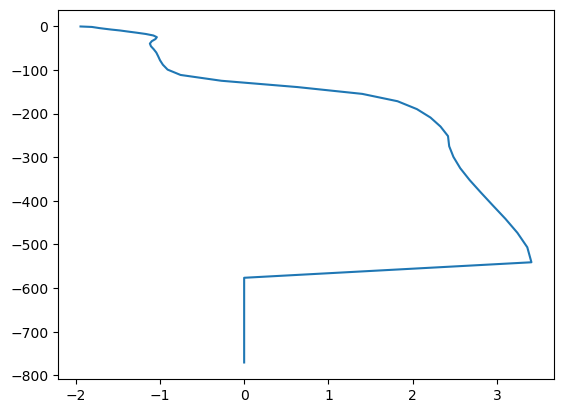

In [18]:
T_profile = TS[0,:,461,459]
plt.plot(T_profile, -z)

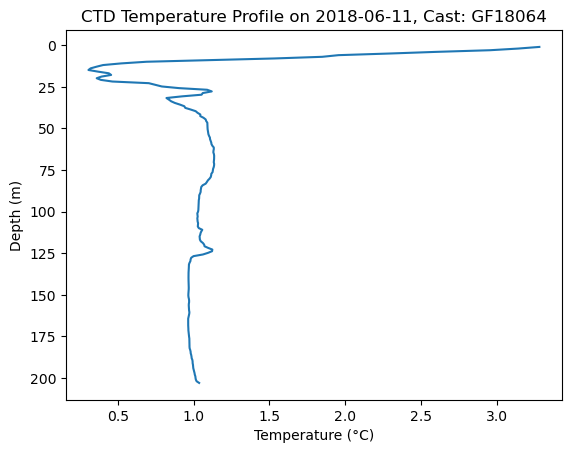

In [19]:
df_cast = df[df['cast'] == 'GF18064']

plt.plot(df_cast["temperature_degC"], df_cast["depth_m"])
plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title(f"CTD Temperature Profile on {start}, Cast: GF18064")
plt.show()

In [20]:
from scipy.interpolate import interp1d
from scipy import stats

In [21]:
set_int = interp1d(z, T_profile) # maps z to T-profile


T_profile_interpolated = set_int(df_cast["depth_m"]) # give it new z values, gives back the T-profile values for those new z vals

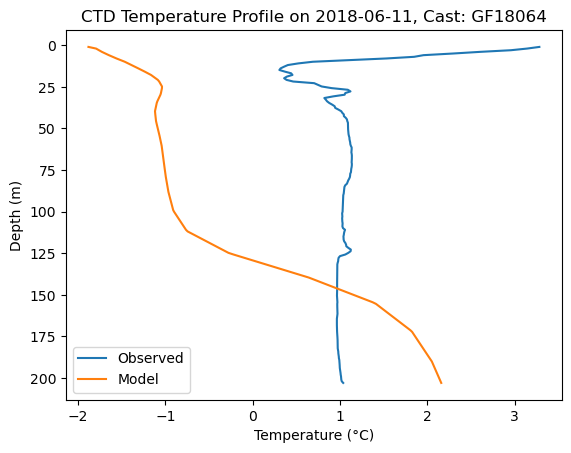

In [22]:
plt.plot(df_cast["temperature_degC"], df_cast["depth_m"], label="Observed")
plt.plot(T_profile_interpolated, df_cast["depth_m"], label = "Model")
plt.gca().invert_yaxis()

plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.legend()
plt.title(f"CTD Temperature Profile on {start}, Cast: GF18064")
plt.show()

In [23]:
observed = df_cast["temperature_degC"].to_numpy()
modeled = T_profile_interpolated

error = modeled - observed

mean_bias = np.mean(error)
rmse = np.sqrt(np.mean(error**2))
correlation, pvalue = stats.pearsonr(observed, modeled)

print("Mean Bias: ", mean_bias)
print("RMSE: ", rmse)
print("Correlation: ", correlation)
print("P-value: ", pvalue)

Mean Bias:  -1.1288627826585396
RMSE:  1.784445099563239
Correlation:  -0.1894391737779946
P-value:  0.006519337210678621
